<a href="https://colab.research.google.com/github/qorrnsu/-PROJECT221012/blob/main/2%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Computer Vision**

**HW_#2-1**

Fig3.9(a) 영상에 대해 오른쪽과 같은 결과가
나오도록 여러가지 경우에 대해 실험하고 결과를 분석해보세요.

In [14]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving 001_Fig0309(a)(washed_out_aerial_image).tif to 001_Fig0309(a)(washed_out_aerial_image).tif


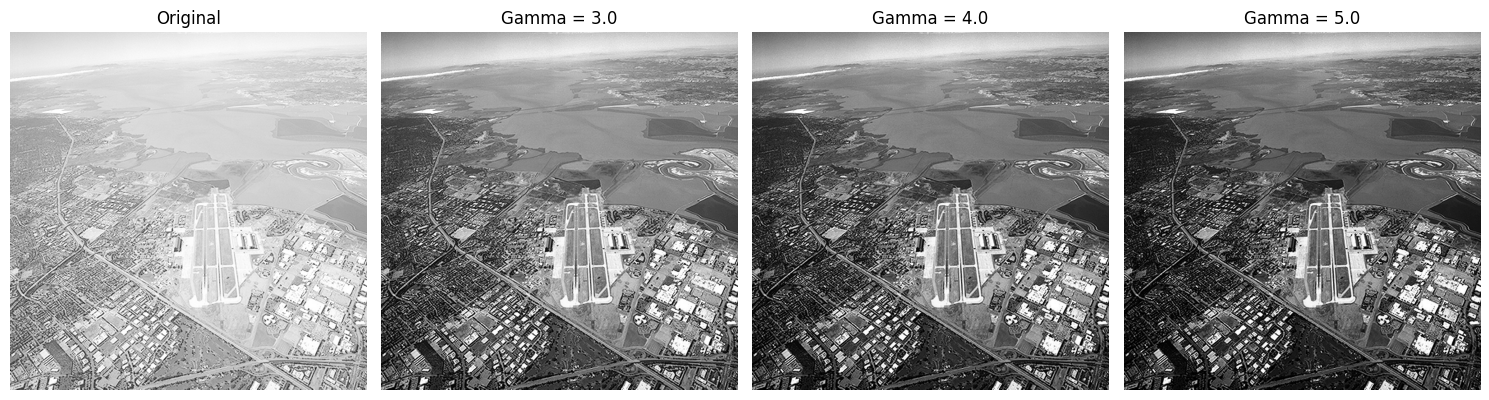

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 파일명
filename = '001_Fig0309(a)(washed_out_aerial_image).tif'

# 이미지 정규화
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("이미지를 불러오지 못했습니다.")
img = img / 255.0

# 감마 변환 함수
def gamma_transform(img, gamma, c=1.0):
    return np.clip(c * np.power(img, gamma), 0, 1)

# 감마 값 리스트
gamma_values = [3.0, 4.0, 5.0]
transformed_images = [gamma_transform(img, g) for g in gamma_values]

# 결과 시각화
plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, gamma_img in enumerate(transformed_images):
    plt.subplot(1, 4, i + 2)
    plt.imshow(gamma_img, cmap='gray')
    plt.title(f'Gamma = {gamma_values[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

**감마 변환 결과 분석**

- **Gamma = 3.0**  
  대비가 향상되어 영상이 더 선명해졌고, 흐릿한 구조물이 뚜렷하게 보인다.

- **Gamma = 4.0**  
  더 어두운 부분까지 명확하게 보이며, 전체적인 디테일이 향상된다.

- **Gamma = 5.0**  
  너무 어두워져 일부 영역의 정보가 손실되지만, 특정 구조는 더 또렷하게 강조된다.

---

**결론**: 감마 보정은 흐릿한 영상을 개선하는 효과적인 방법이며, 적절한 감마 값을 선택하는 것이 중요하다. 일반적으로 Gamma = 3.0 ~ 4.0 범위가 적절하다.


**HW_#2-2**

Fig3.10(a) 영상에 대해 오른쪽과 같은 결과가 나오도록 여러가지 경우에 대해 실험하고 결과를 분석해보세요.

Saving 002_Fig0310(b)(washed_out_pollen_image).tif to 002_Fig0310(b)(washed_out_pollen_image) (7).tif


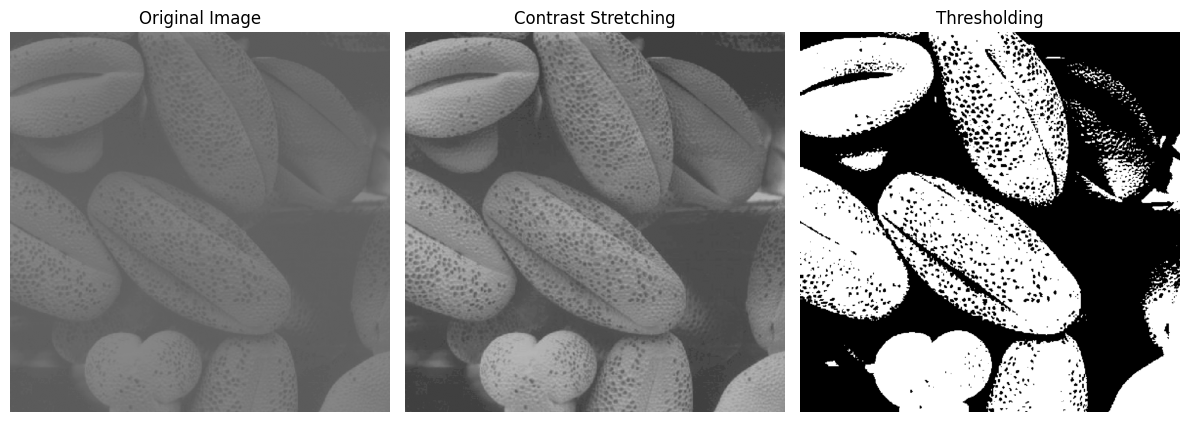

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 이미지 업로드
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
img_original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# 정규화 (0~1)
img_normalized = img_original.astype(np.float32) / 255.0

# Contrast Stretching 함수
def contrast_stretch(img, r1, r2, s1, s2):
    out = np.zeros_like(img)
    mask1 = img <= r1
    mask2 = (img > r1) & (img <= r2)
    mask3 = img > r2

    out[mask1] = (s1 / r1) * img[mask1]
    out[mask2] = ((s2 - s1) / (r2 - r1)) * (img[mask2] - r1) + s1
    out[mask3] = ((1 - s2) / (1 - r2)) * (img[mask3] - r2) + s2

    return np.clip(out, 0, 1)

# Thresholding 함수
def thresholding(img, thresh=0.45):
    return (img > thresh).astype(np.float32)

# 파라미터 설정
r1, r2 = 0.3, 0.6
s1, s2 = 0.1, 0.9
thresh = 0.45

# Contrast Stretching 적용
img_stretched = contrast_stretch(img_normalized, r1, r2, s1, s2)

# Thresholding 적용
img_thresholded = thresholding(img_stretched, thresh)

# 결과 시각화
plt.figure(figsize=(12, 5))
titles = ['Original Image', 'Contrast Stretching', 'Thresholding']
images = [
    img_original,
    (img_stretched * 255).astype(np.uint8),
    (img_thresholded * 255).astype(np.uint8)
]

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

**이미지 변환 결과 분석**

- **Original Image**  
  원본 이미지는 명암 범위가 좁은 전형적인 low-contrast 이미지로 세포 구조가 흐릿하게 나타난다.

- **Contrast Stretching**  
  Contrast Stretching 결과는 밝은 부분은 더 밝아지고 어두운 부분은 더 어둡게 조정되어 세포의 경계와 디테일이 강조된다.

- **Thresholding**  
  Thresholding 결과는 설정한 임계값을 기준으로 밝은 영역만 흰색으로 표시하여 객체 형태가 잘 드러나고 분석이나 분할에 용이한 이미지로 바뀐다.

**HW_#2-3**

임의의 영상을 입력 받아 아래와 같은 마스크를 사용하여 컨볼루션 하고, 그 결과를 분석해보세요.

**HW_#2-4**

아래와 같은 영상에 대하여 45°, -45° 방향의 대각선 edge를 검출하되, Sobel 연산자를 변형하여 적절한 마스크를 만들어 적용해보세요.

Saving 004_school.jpg to 004_school (1).jpg


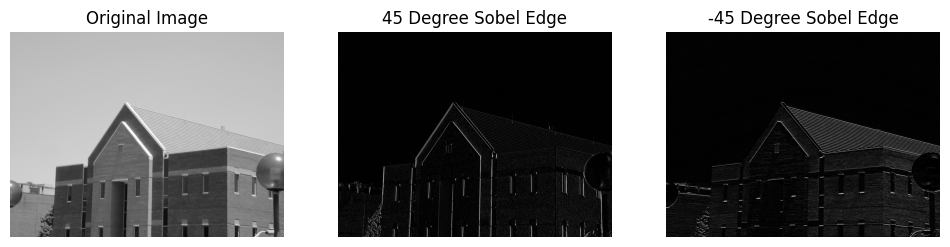

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Sobel 연산자 적용 (45도 방향)
sobel_45 = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])  # 45도 엣지
sobel_45_result = cv2.filter2D(image, -1, sobel_45)

# Sobel 연산자 적용 (-45도 방향)
sobel_neg45 = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])  # -45도 엣지
sobel_neg45_result = cv2.filter2D(image, -1, sobel_neg45)

# 결과 시각화
plt.figure(figsize=(12, 6))

# 원본 이미지
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# 45도 Sobel 엣지
plt.subplot(1, 3, 2)
plt.imshow(sobel_45_result, cmap='gray')
plt.title('45 Degree Sobel Edge')
plt.axis('off')

# -45도 Sobel 엣지
plt.subplot(1, 3, 3)
plt.imshow(sobel_neg45_result, cmap='gray')
plt.title('-45 Degree Sobel Edge')
plt.axis('off')

# 결과 표시
plt.show()

**이미지 변환 결과 분석**

- **45도 Sobel 엣지**  
  대각선 방향의 엣지가 강조되어 건물의 외벽과 지붕 경계가 뚜렷하게 나타남.

- **-45도 Sobel 엣지**  
  반대 방향의 대각선 엣지가 강조되어 건물의 경계가 또렷하게 드러남.

**HW_#2-5**

왼쪽의 지문영상을 오른쪽 영상과 같이 개선해보세요. 수업시간에 배운 방법을 기본적으로 적용해보고, 더 좋은 방법이 있으면 해당 방법도 적용하고 결과를 분석해보세요.

Saving 005_finger.jpg to 005_finger (27).jpg
Original Image Edges:


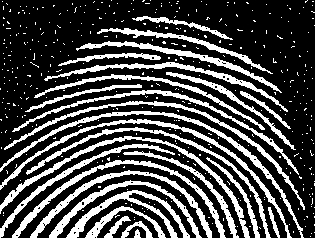

Filtered Image Edges:


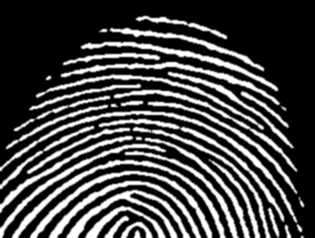

In [59]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 1. 미디언 필터 적용 (하얀 노이즈 제거)
median_filtered = cv2.medianBlur(image, 5)

# 2. GaussianBlur 적용 (경계만 부드럽게 처리)
blurred_image = cv2.GaussianBlur(median_filtered, (3, 3), 0)


# 결과 비교
print("Original Image Edges:")
cv2_imshow(image)

print("Filtered Image Edges:")
cv2_imshow(blurred_image)

**이미지 변환 결과 분석**

- **Median Filter**  
  Median Filter를 적용하여 이미지의 텍스처와 세부 정보는 보존하되 하얀 노이즈를 제거함.

- **Gaussian Blur**  
  Gaussian Blur를 적용하여 지문 결 같은 세부 디테일이 부드러운 효과를 주었지만, 과하지 않도록 커널 크기 (3, 3)를 사용하여 흐림 효과를 적당히 유지함.

**HW_#2-6**

다음 영상에서 원하는 선분을 없애 보시고 어떻게 했는지 분석하세요.

Saving 006_Fig0905(a)(wirebond-mask).tif to 006_Fig0905(a)(wirebond-mask) (2).tif


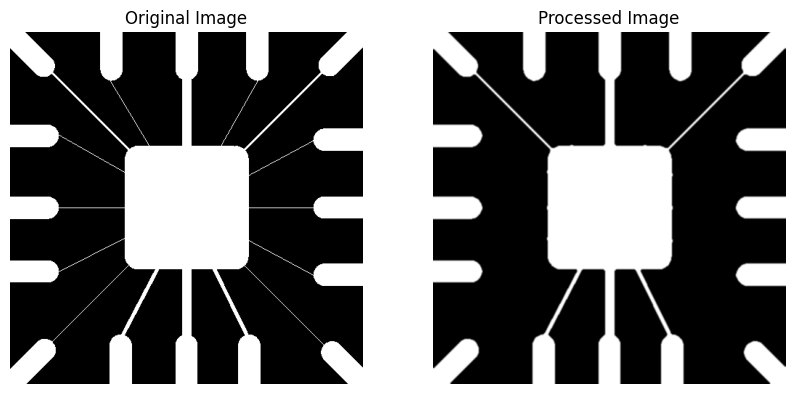

In [64]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 미디언 필터로 노이즈 제거
median_filtered = cv2.medianBlur(image, 5)

# GaussianBlur 적용 (경계 부드럽게 처리)
blurred_image = cv2.GaussianBlur(median_filtered, (3, 3), 0)

# 결과 비교
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 원본 이미지
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# 처리된 이미지
axes[1].imshow(blurred_image, cmap='gray')
axes[1].set_title("Processed Image")
axes[1].axis('off')

plt.show()

**선분 제거 결과 분석**


이미지에서 선분을 없애기 위해 두 가지 필터를 적용했음

1.  Median Filter를 사용하여 이미지의 하얀 노이즈를 제거함

    각 픽셀을 주변 픽셀의 중앙값으로 대체하여 노이즈를 줄이고, 불필요한 세부 사항을 부드럽게 만듬.

2. GaussianBlur를 적용하여 경계를 부드럽게 처리함
    
    이미지에 흐림 효과를 주어 선이나 경계를 부드럽게 만들어 더 자연스럽게 보이게 함.

결과적으로, 처리된 이미지는 원본보다 선명한 경계선이 사라지고 더 부드러운 느낌을 줌.

**HW_#2-7**

아래의 Edge 검출 알고리즘 사용하여 edge를 검출하고, 각각 결과가 어떻게 다른 지 비교하세요.

*   Sobel
*   Laplacian
*   Canny
*   Morphological Gradient


Saving 007_Fig0939(a)(headCT-Vandy).tif to 007_Fig0939(a)(headCT-Vandy).tif


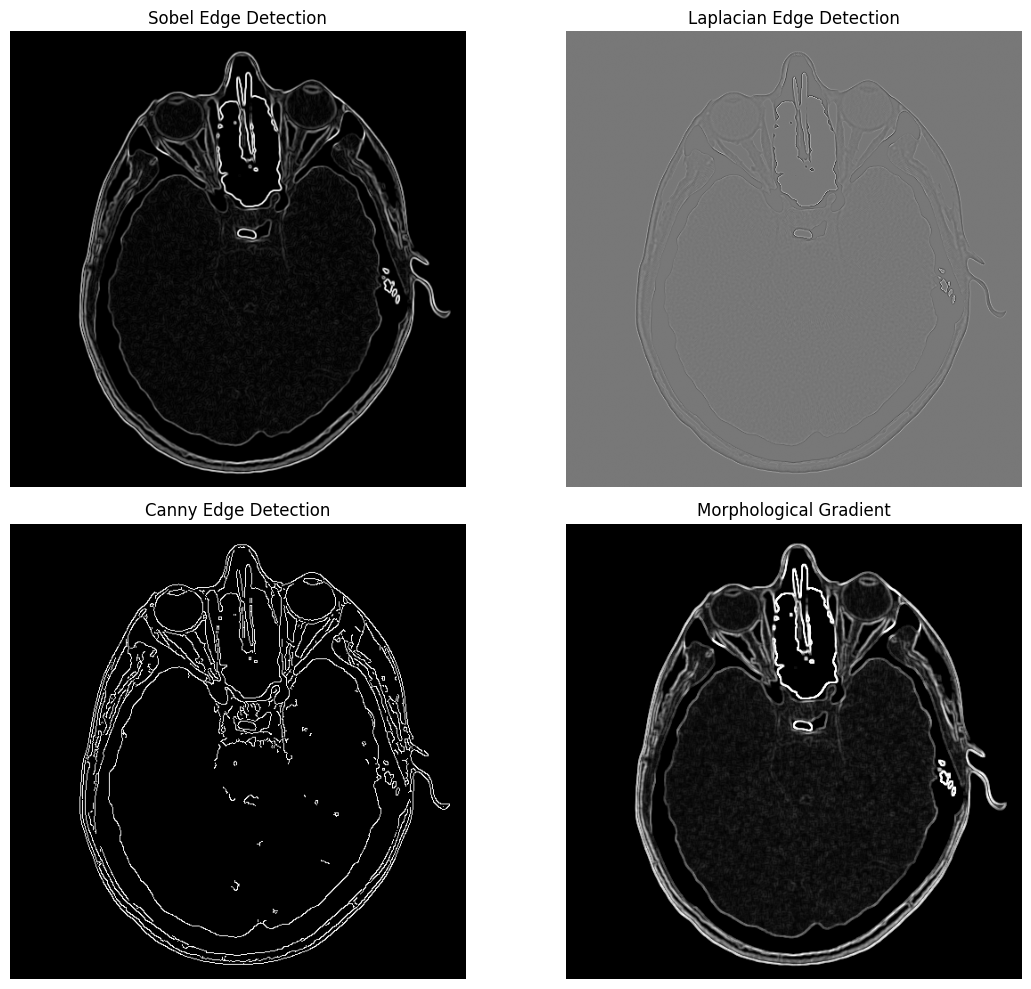

In [65]:
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Sobel 엣지 검출
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel_edges = cv2.magnitude(sobel_x, sobel_y)

# Laplacian 엣지 검출
laplacian_edges = cv2.Laplacian(image, cv2.CV_64F)

# Canny 엣지 검출
canny_edges = cv2.Canny(image, 100, 200)

# Morphological Gradient
kernel = np.ones((3, 3), np.uint8)
morph_gradient = cv2.morphologyEx(image, cv2.MORPH_GRADIENT, kernel)

# 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sobel
axes[0, 0].imshow(sobel_edges, cmap='gray')
axes[0, 0].set_title('Sobel Edge Detection')
axes[0, 0].axis('off')

# Laplacian
axes[0, 1].imshow(laplacian_edges, cmap='gray')
axes[0, 1].set_title('Laplacian Edge Detection')
axes[0, 1].axis('off')

# Canny
axes[1, 0].imshow(canny_edges, cmap='gray')
axes[1, 0].set_title('Canny Edge Detection')
axes[1, 0].axis('off')

# Morphological Gradient
axes[1, 1].imshow(morph_gradient, cmap='gray')
axes[1, 1].set_title('Morphological Gradient')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

**Sobel Edge Detection:**
Sobel은 수평 및 수직 방향의 엣지를 검출한다. 이 방법은 이미지의 경계선을 강조하는데 효과적이며 수평과 수직의 경계가 잘 강조된 형태를 보여준다.

**Laplacian Edge Detection:**
Laplacian은 2차 미분을 사용하여 이미지의 변화가 큰 부분을 찾아낸다.

**Canny Edge Detection:**
Canny는 다단계로 엣지를 검출하는 방법으로 정확한 엣지를 추출하는데 유용하다. 경계가 더 부드럽고 정밀한 형태로 나타나며, 잡음이 적고 잘 정의된 엣지를 찾는데 유리하다.

**Morphological Gradient:**
Morphological Gradient는 팽창과 침식 연산을 사용하여 엣지를 검출한다. 이 방법은 객체의 경계를 강조하고 더 두드러지게 만들어준다.

**HW_#2-8**

아래의 알고리즘을 사용하여 노이즈라 생각되는 영역을 지우고, 각각 결과가 어떻게 다른지 비교 분석하세요.
*   Morphological Smoothing
*   Smoothing Filter


Saving 008_Fig0938(a)(cygnusloop_Xray_original).tif to 008_Fig0938(a)(cygnusloop_Xray_original) (1).tif


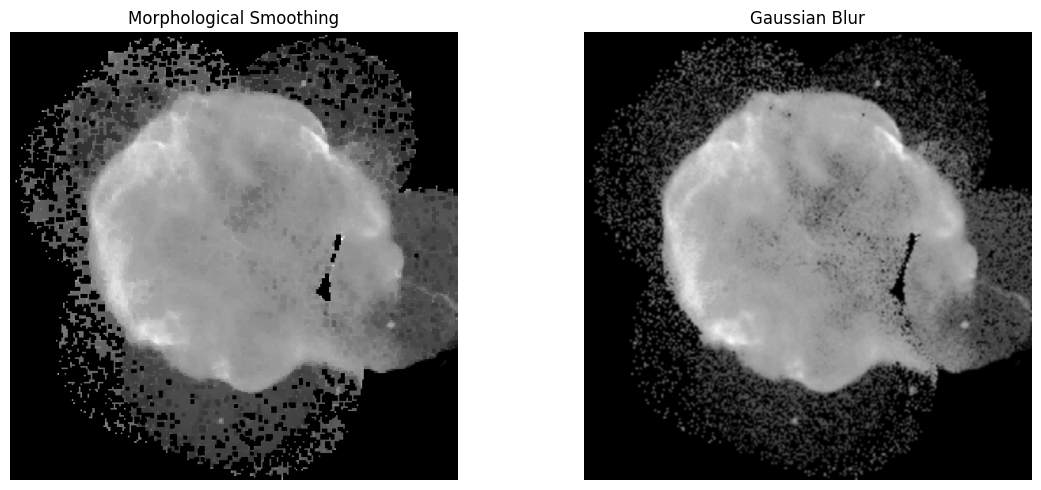

In [67]:
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Morphological Smoothing
kernel = np.ones((5, 5), np.uint8)  # 5x5 크기의 커널을 사용
morph_smooth = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

# Gaussian Blur
smooth_filter = cv2.GaussianBlur(image, (5, 5), 0)

# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Morphological Smoothing 결과
axes[0].imshow(morph_smooth, cmap='gray')
axes[0].set_title('Morphological Smoothing')
axes[0].axis('off')

# Gaussian Blur 결과
axes[1].imshow(smooth_filter, cmap='gray')
axes[1].set_title('Gaussian Blur')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Morphological Smoothing:**

팽창(dilation)과 침식(erosion)을 결합하여 작은 노이즈를 제거하고, 이미지에서 불규칙한 부분을 평탄화하는데 사용함. cv2.MORPH_CLOSE 연산을 사용하여, 작은 구멍이나 노이즈를 채우고 부드러운 경계를 생성했음.

**Gaussian Blur:**

Gaussian Blur는 고주파 노이즈를 제거하는 데 효과적이며, 이미지의 선이나 경계를 부드럽게 처리함. 그러나 너무 강하게 적용되면 세부 사항을 흐리게 만들 수 있음.

**비교 분석:**

Morphological Smoothing은 이미지에서 구멍이나 작은 노이즈를 효과적으로 제거하는데 유리하며, 전체적으로 이미지의 형태를 유지하면서 부드럽게 만듬.

Gaussian Blur는 부드럽게 처리하여 노이즈를 제거하지만, 경계나 세부적인 부분까지 영향을 미쳐서 약간의 디테일 손실이 있을 수 있음.

**HW_#2-9**

다음 영상을 이진화하되, 수업시간에 배운 2가지 방법을 모두 써보고, 각각의 결과에 대해 비교 분석하세요.

Saving 009_Fig0940(a)(rice_image_with_intensity_gradient).tif to 009_Fig0940(a)(rice_image_with_intensity_gradient) (3).tif


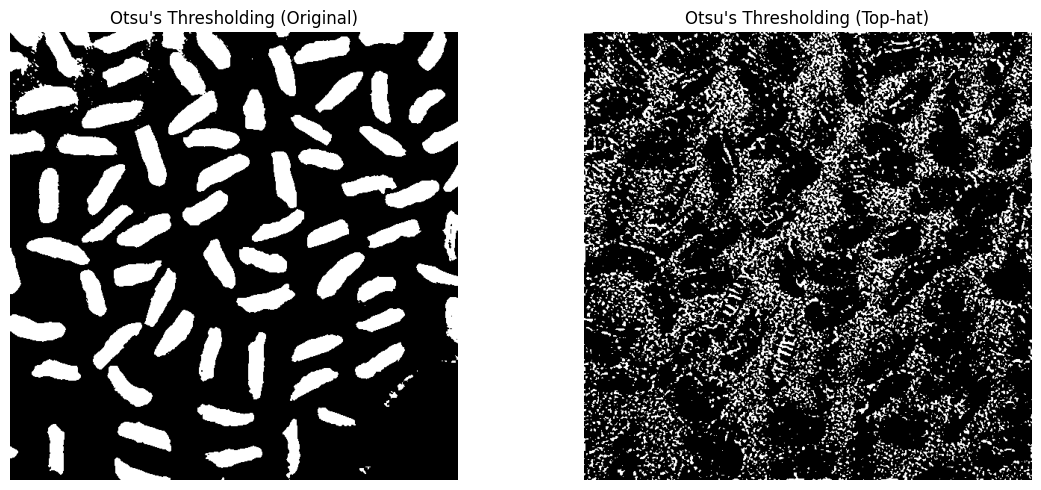

In [71]:
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 원본 영상에 대해 Otsu's Thresholding 적용
_, otsu_thresholded_original = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Top-hat 변환
kernel = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
top_hat_result = cv2.subtract(image, opening)

# Top-hat 변환 결과에 대해 Otsu's Thresholding 적용
_, otsu_thresholded_top_hat = cv2.threshold(top_hat_result, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 원본 영상에 대한 Otsu 이진화 결과
axes[0].imshow(otsu_thresholded_original, cmap='gray')
axes[0].set_title("Otsu's Thresholding (Original)")
axes[0].axis('off')

# Top-hat 변환 결과에 대한 Otsu 이진화
axes[1].imshow(otsu_thresholded_top_hat, cmap='gray')
axes[1].set_title("Otsu's Thresholding (Top-hat)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

**원본 영상에 대한 Otsu's Thresholding:**

원본 이미지에 대해 Otsu의 자동 임계값 계산을 통해 이진화한 결과이다. Otsu 방법은 이미지의 히스토그램을 분석하여 가장 적합한 임계값을 자동으로 찾아 배경과 객체를 구분한다.

**Top-hat 변환 결과 영상에 대한 Otsu's Thresholding:**

먼저 Top-hat 변환을 적용하여 이미지의 작은 밝은 부분을 강조한 후, 그 결과에 대해 Otsu's Thresholding을 적용한 결과이다. 이 방법은 이미지에서 강조된 밝은 부분을 기반으로 이진화를 수행하여 세부적인 정보가 더 잘 나타나도록 한다.

**HW_#2-10**

다음 영상을 Morphology를 적용하여 오른쪽과 같이 분할하세요.

Saving 010_Fig0943(a)(dark_blobs_on_light_background).tif to 010_Fig0943(a)(dark_blobs_on_light_background) (11).tif


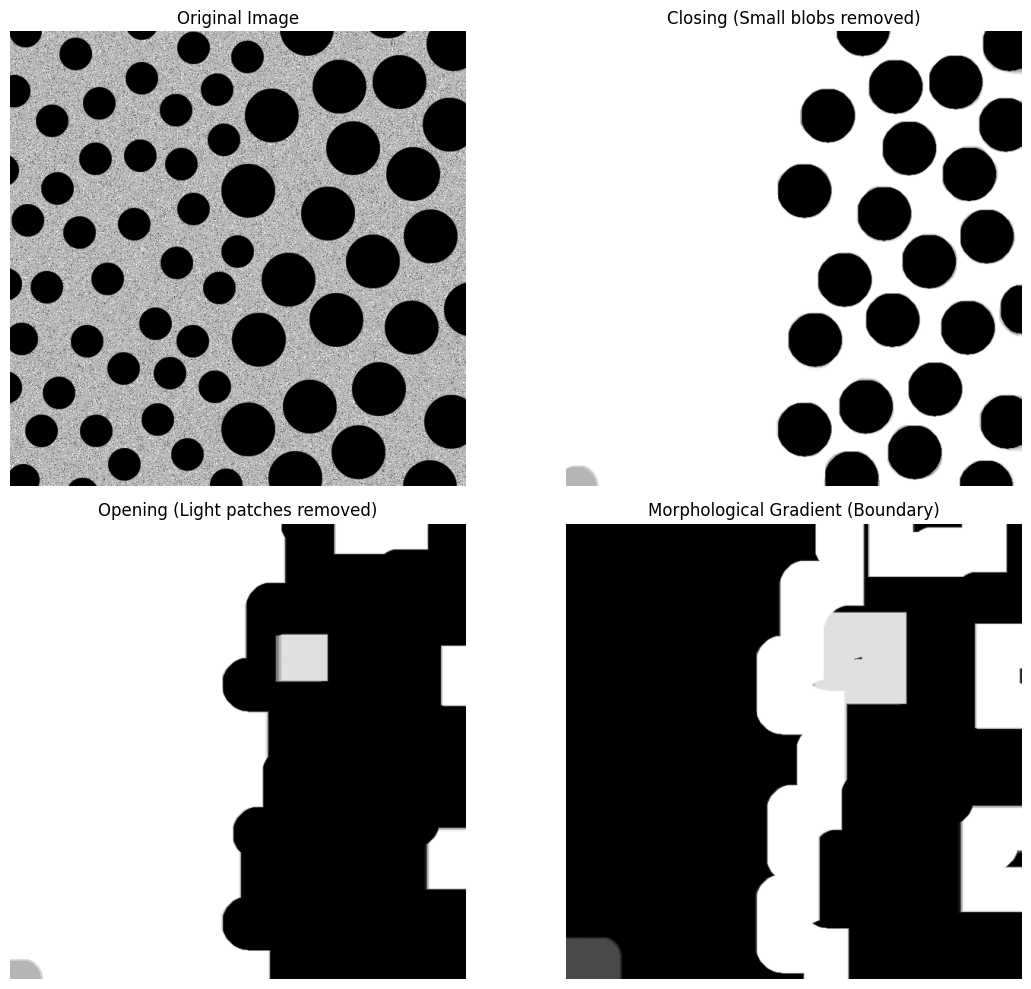

In [85]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 업로드
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Closing 연산을 적용하여 작은 블롭을 제거
kernel_close_circle = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (50, 50))
closing_image = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel_close_circle)

# Opening 연산을 적용하여 큰 블롭 사이의 밝은 영역 제거
kernel = np.ones((60, 60), np.uint8)  # 커널 크기 설정
opening_result = cv2.morphologyEx(closing_image, cv2.MORPH_OPEN, kernel)

# Morphological Gradient (경계 추출)
morph_gradient = cv2.morphologyEx(opening_result, cv2.MORPH_GRADIENT, kernel)

# 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 원본 이미지
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

# Closing 결과
axes[0, 1].imshow(closing_image, cmap='gray')
axes[0, 1].set_title("Closing (Small blobs removed)")
axes[0, 1].axis('off')

# Opening 결과
axes[1, 0].imshow(opening_result, cmap='gray')
axes[1, 0].set_title("Opening (Light patches removed)")
axes[1, 0].axis('off')

# Morphological Gradient 경계
axes[1, 1].imshow(morph_gradient, cmap='gray')
axes[1, 1].set_title("Morphological Gradient (Boundary)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()